# Notebook 1: Khảo Sát và Tiền Xử Lý Dữ Liệu (EDA)
## Đồ án: Ứng dụng Decision Tree trong dự đoán hiệu quả chiến dịch tiếp thị ngân hàng

**Dataset:** UCI Bank Marketing (41,188 bản ghi × 21 thuộc tính)  
**Mục tiêu:** Khảo sát, tiền xử lý, và phân tích dữ liệu trước khi xây dựng mô hình.


In [1]:
# ====== SETUP CHO GOOGLE COLAB ======
# Chạy cell này ĐẦU TIÊN khi dùng Colab
import os

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Đường dẫn tới project trên Drive
PROJECT_DIR = '/content/drive/MyDrive/kpdl'
os.chdir(PROJECT_DIR)

# Thêm src/ vào Python path
import sys
sys.path.insert(0, PROJECT_DIR)

print(f'Working directory: {os.getcwd()}')
print(f'Files: {os.listdir(".")}')
print('✅ Setup complete!')

Mounted at /content/drive
Working directory: /content/drive/MyDrive/kpdl
Files: ['report', 'data', 'src', 'notebooks']
✅ Setup complete!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Style settings
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('husl')

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 1. Tổng quan bộ dữ liệu

Bộ dữ liệu Bank Marketing được thu thập từ các chiến dịch tiếp thị qua điện thoại  
của một ngân hàng tại Bồ Đào Nha (05/2008 – 11/2010).  
**Nguồn:** Moro et al. (2014), UCI Machine Learning Repository.


In [3]:
# Load dataset
df = pd.read_csv("data/bank-additional/bank-additional-full.csv", sep=";")

print(f"Kích thước dataset: {df.shape[0]:,} bản ghi × {df.shape[1]} thuộc tính")
print(f"Danh sách thuộc tính ({df.shape[1]} cột):")
for i, col in enumerate(df.columns):
    print(f"{i+1:2d}. {col} ({df[col].dtype})")


Kích thước dataset: 41,188 bản ghi × 21 thuộc tính
Danh sách thuộc tính (21 cột):
 1. age (int64)
 2. job (object)
 3. marital (object)
 4. education (object)
 5. default (object)
 6. housing (object)
 7. loan (object)
 8. contact (object)
 9. month (object)
10. day_of_week (object)
11. duration (int64)
12. campaign (int64)
13. pdays (int64)
14. previous (int64)
15. poutcome (object)
16. emp.var.rate (float64)
17. cons.price.idx (float64)
18. cons.conf.idx (float64)
19. euribor3m (float64)
20. nr.employed (float64)
21. y (object)


In [4]:
# Xem 5 dòng đầu
df.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
# Thông tin kiểu dữ liệu và null
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [6]:
# Thống kê mô tả cho biến numeric
df.describe().round(2)


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00
mean,40.02,258.29,2.57,962.48,0.17,0.08,93.58,-40.50,3.62,5167.04
std,10.42,259.28,2.77,186.91,0.49,1.57,0.58,4.63,1.73,72.25
min,17.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,32.00,102.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,180.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,319.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,98.00,4918.00,56.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10


## 2. Mô tả thuộc tính

| # | Thuộc tính | Kiểu | Ý nghĩa |
|---|---|---|---|
| 1 | age | int | Tuổi khách hàng |
| 2 | job | category | Nghề nghiệp |
| 3 | marital | category | Tình trạng hôn nhân |
| 4 | education | category | Trình độ học vấn |
| 5 | default | category | Có nợ xấu không? |
| 6 | housing | category | Có vay mua nhà không? |
| 7 | loan | category | Có vay tiêu dùng không? |
| 8 | contact | category | Phương thức liên hệ |
| 9 | month | category | Tháng gọi |
| 10 | day_of_week | category | Ngày trong tuần |
| 11 | duration | int | Thời lượng cuộc gọi (giây) |
| 12 | campaign | int | Số lần liên hệ trong chiến dịch |
| 13 | pdays | int | Số ngày từ lần gọi trước (999 = chưa gọi) |
| 14 | previous | int | Số lần liên hệ trước đó |
| 15 | poutcome | category | Kết quả chiến dịch trước |
| 16 | emp.var.rate | float | Tỷ lệ biến động việc làm |
| 17 | cons.price.idx | float | Chỉ số giá tiêu dùng |
| 18 | cons.conf.idx | float | Chỉ số niềm tin tiêu dùng |
| 19 | euribor3m | float | Lãi suất Euribor 3 tháng |
| 20 | nr.employed | float | Số người đang được tuyển dụng |
| 21 | **y** | **binary** | **Có gửi tiết kiệm không? (TARGET)** |


## 3. Tiền xử lý dữ liệu

### 3.1 Bước 1: Kiểm tra giá trị null


In [7]:
# Kiểm tra null
null_counts = df.isnull().sum()
print("Số giá trị null mỗi cột:")
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else "→ Không có giá trị null nào!")
print(f"Tổng null: {null_counts.sum()}")


Số giá trị null mỗi cột:
→ Không có giá trị null nào!
Tổng null: 0


### 3.2 Bước 2: Kiểm tra giá trị implicit missing ("unknown")


In [8]:
# Kiểm tra giá trị "unknown"
print("Số giá trị 'unknown' trong từng cột:")
print("=" * 40)
for col in df.select_dtypes(include="object").columns:
    unknown_count = (df[col] == "unknown").sum()
    if unknown_count > 0:
        pct = unknown_count / len(df) * 100
        print(f"  {col:15s}: {unknown_count:5d} ({pct:.1f}%)")

print(f"→ Quyết định: Giữ 'unknown' vì chiếm tỷ lệ nhỏ, xóa sẽ mất dữ liệu.")


Số giá trị 'unknown' trong từng cột:
  job            :   330 (0.8%)
  marital        :    80 (0.2%)
  education      :  1731 (4.2%)
  default        :  8597 (20.9%)
  housing        :   990 (2.4%)
  loan           :   990 (2.4%)
→ Quyết định: Giữ 'unknown' vì chiếm tỷ lệ nhỏ, xóa sẽ mất dữ liệu.


### 3.3 Bước 3: Kiểm tra duplicate


In [9]:
# Kiểm tra trùng lặp
n_dup = df.duplicated().sum()
print(f"Số bản ghi trùng lặp: {n_dup}")
if n_dup > 0:
    df = df.drop_duplicates()
    print(f"Sau khi xóa: {len(df):,} bản ghi")
else:
    print("→ Không có bản ghi trùng lặp.")


Số bản ghi trùng lặp: 12
Sau khi xóa: 41,176 bản ghi


## 4. Khảo sát dữ liệu (EDA)

### 4.1 Phân phối biến mục tiêu (Target Variable)


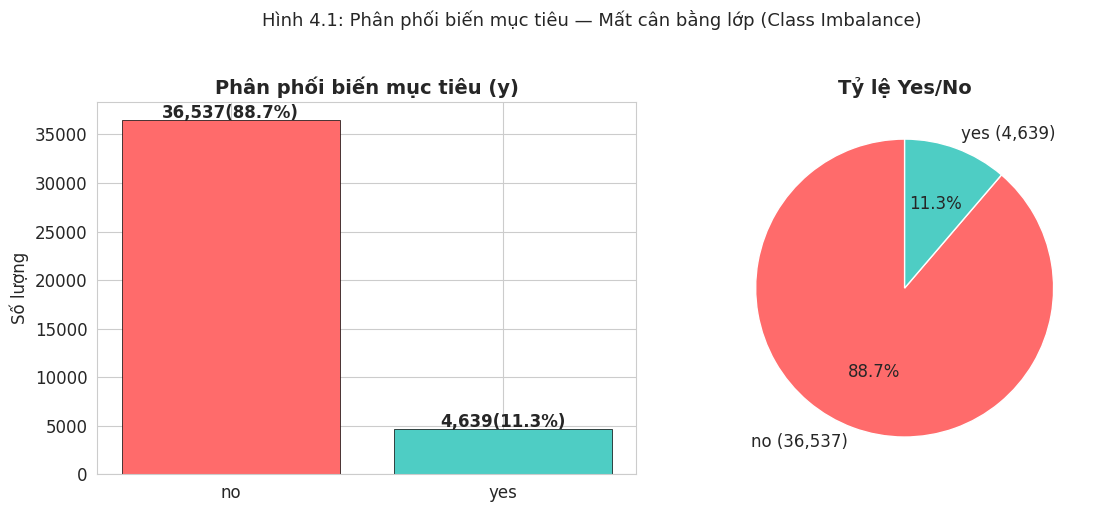

→ Nhận xét: Class imbalance nghiêm trọng — 'no' chiếm 88.7%
   Accuracy có thể misleading, cần dùng Precision/Recall/F1.


In [10]:
# Phân phối biến mục tiêu
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
counts = df["y"].value_counts()
colors = ["#FF6B6B", "#4ECDC4"]
axes[0].bar(counts.index, counts.values, color=colors, edgecolor="black", linewidth=0.5)
for i, (idx, val) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, val + 200, f"{val:,}({val/len(df)*100:.1f}%)",
                ha="center", fontsize=12, fontweight="bold")
axes[0].set_title("Phân phối biến mục tiêu (y)", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Số lượng")

# Pie chart
axes[1].pie(counts.values, labels=[f"{l} ({v:,})" for l, v in zip(counts.index, counts.values)],
           colors=colors, autopct="%1.1f%%", startangle=90, textprops={"fontsize": 12})
axes[1].set_title("Tỷ lệ Yes/No", fontsize=14, fontweight="bold")

plt.suptitle("Hình 4.1: Phân phối biến mục tiêu — Mất cân bằng lớp (Class Imbalance)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("report/fig_4_1_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"→ Nhận xét: Class imbalance nghiêm trọng — 'no' chiếm {counts['no']/len(df)*100:.1f}%")
print(f"   Accuracy có thể misleading, cần dùng Precision/Recall/F1.")


### 4.2 Phân phối biến categorical


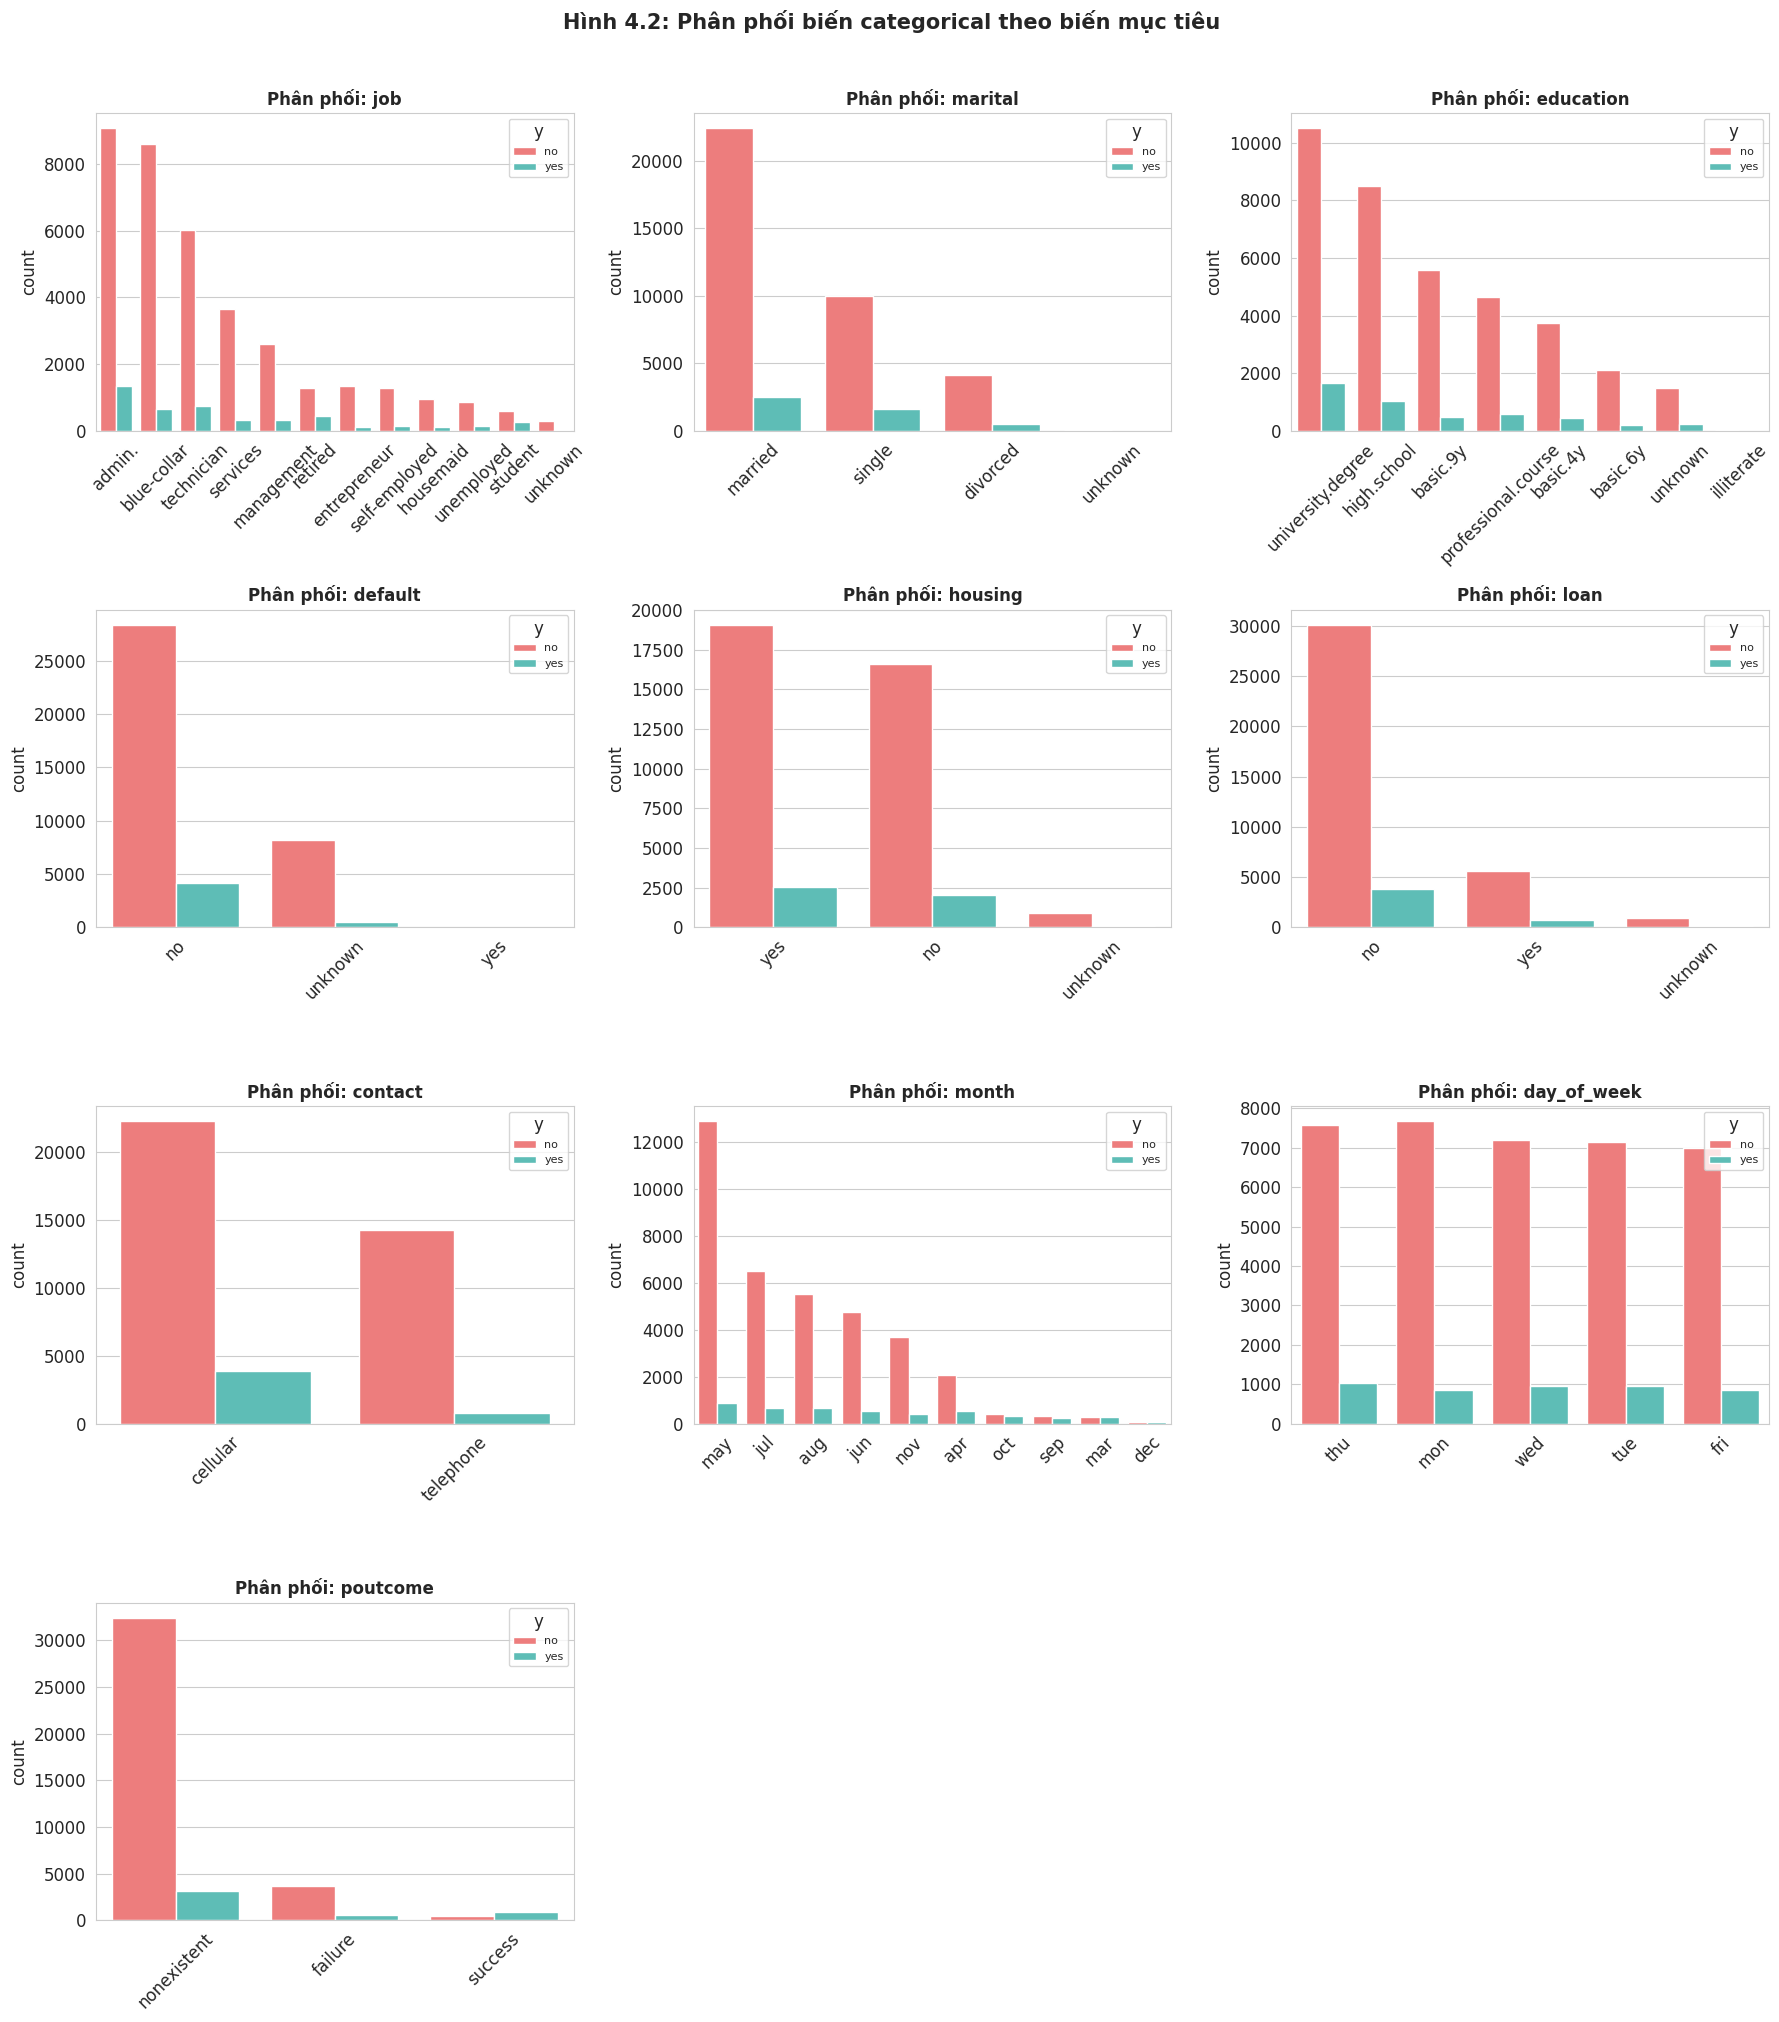

In [11]:
# Phân phối tất cả biến categorical
cat_cols = ["job", "marital", "education", "default", "housing", "loan",
            "contact", "month", "day_of_week", "poutcome"]

fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, hue="y", order=order, ax=ax, palette=["#FF6B6B", "#4ECDC4"])
    ax.set_title(f"Phân phối: {col}", fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(title="y", fontsize=8)

# Ẩn axes thừa
for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Hình 4.2: Phân phối biến categorical theo biến mục tiêu",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("report/fig_4_2_categorical_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


### 4.3 Phân phối biến numeric


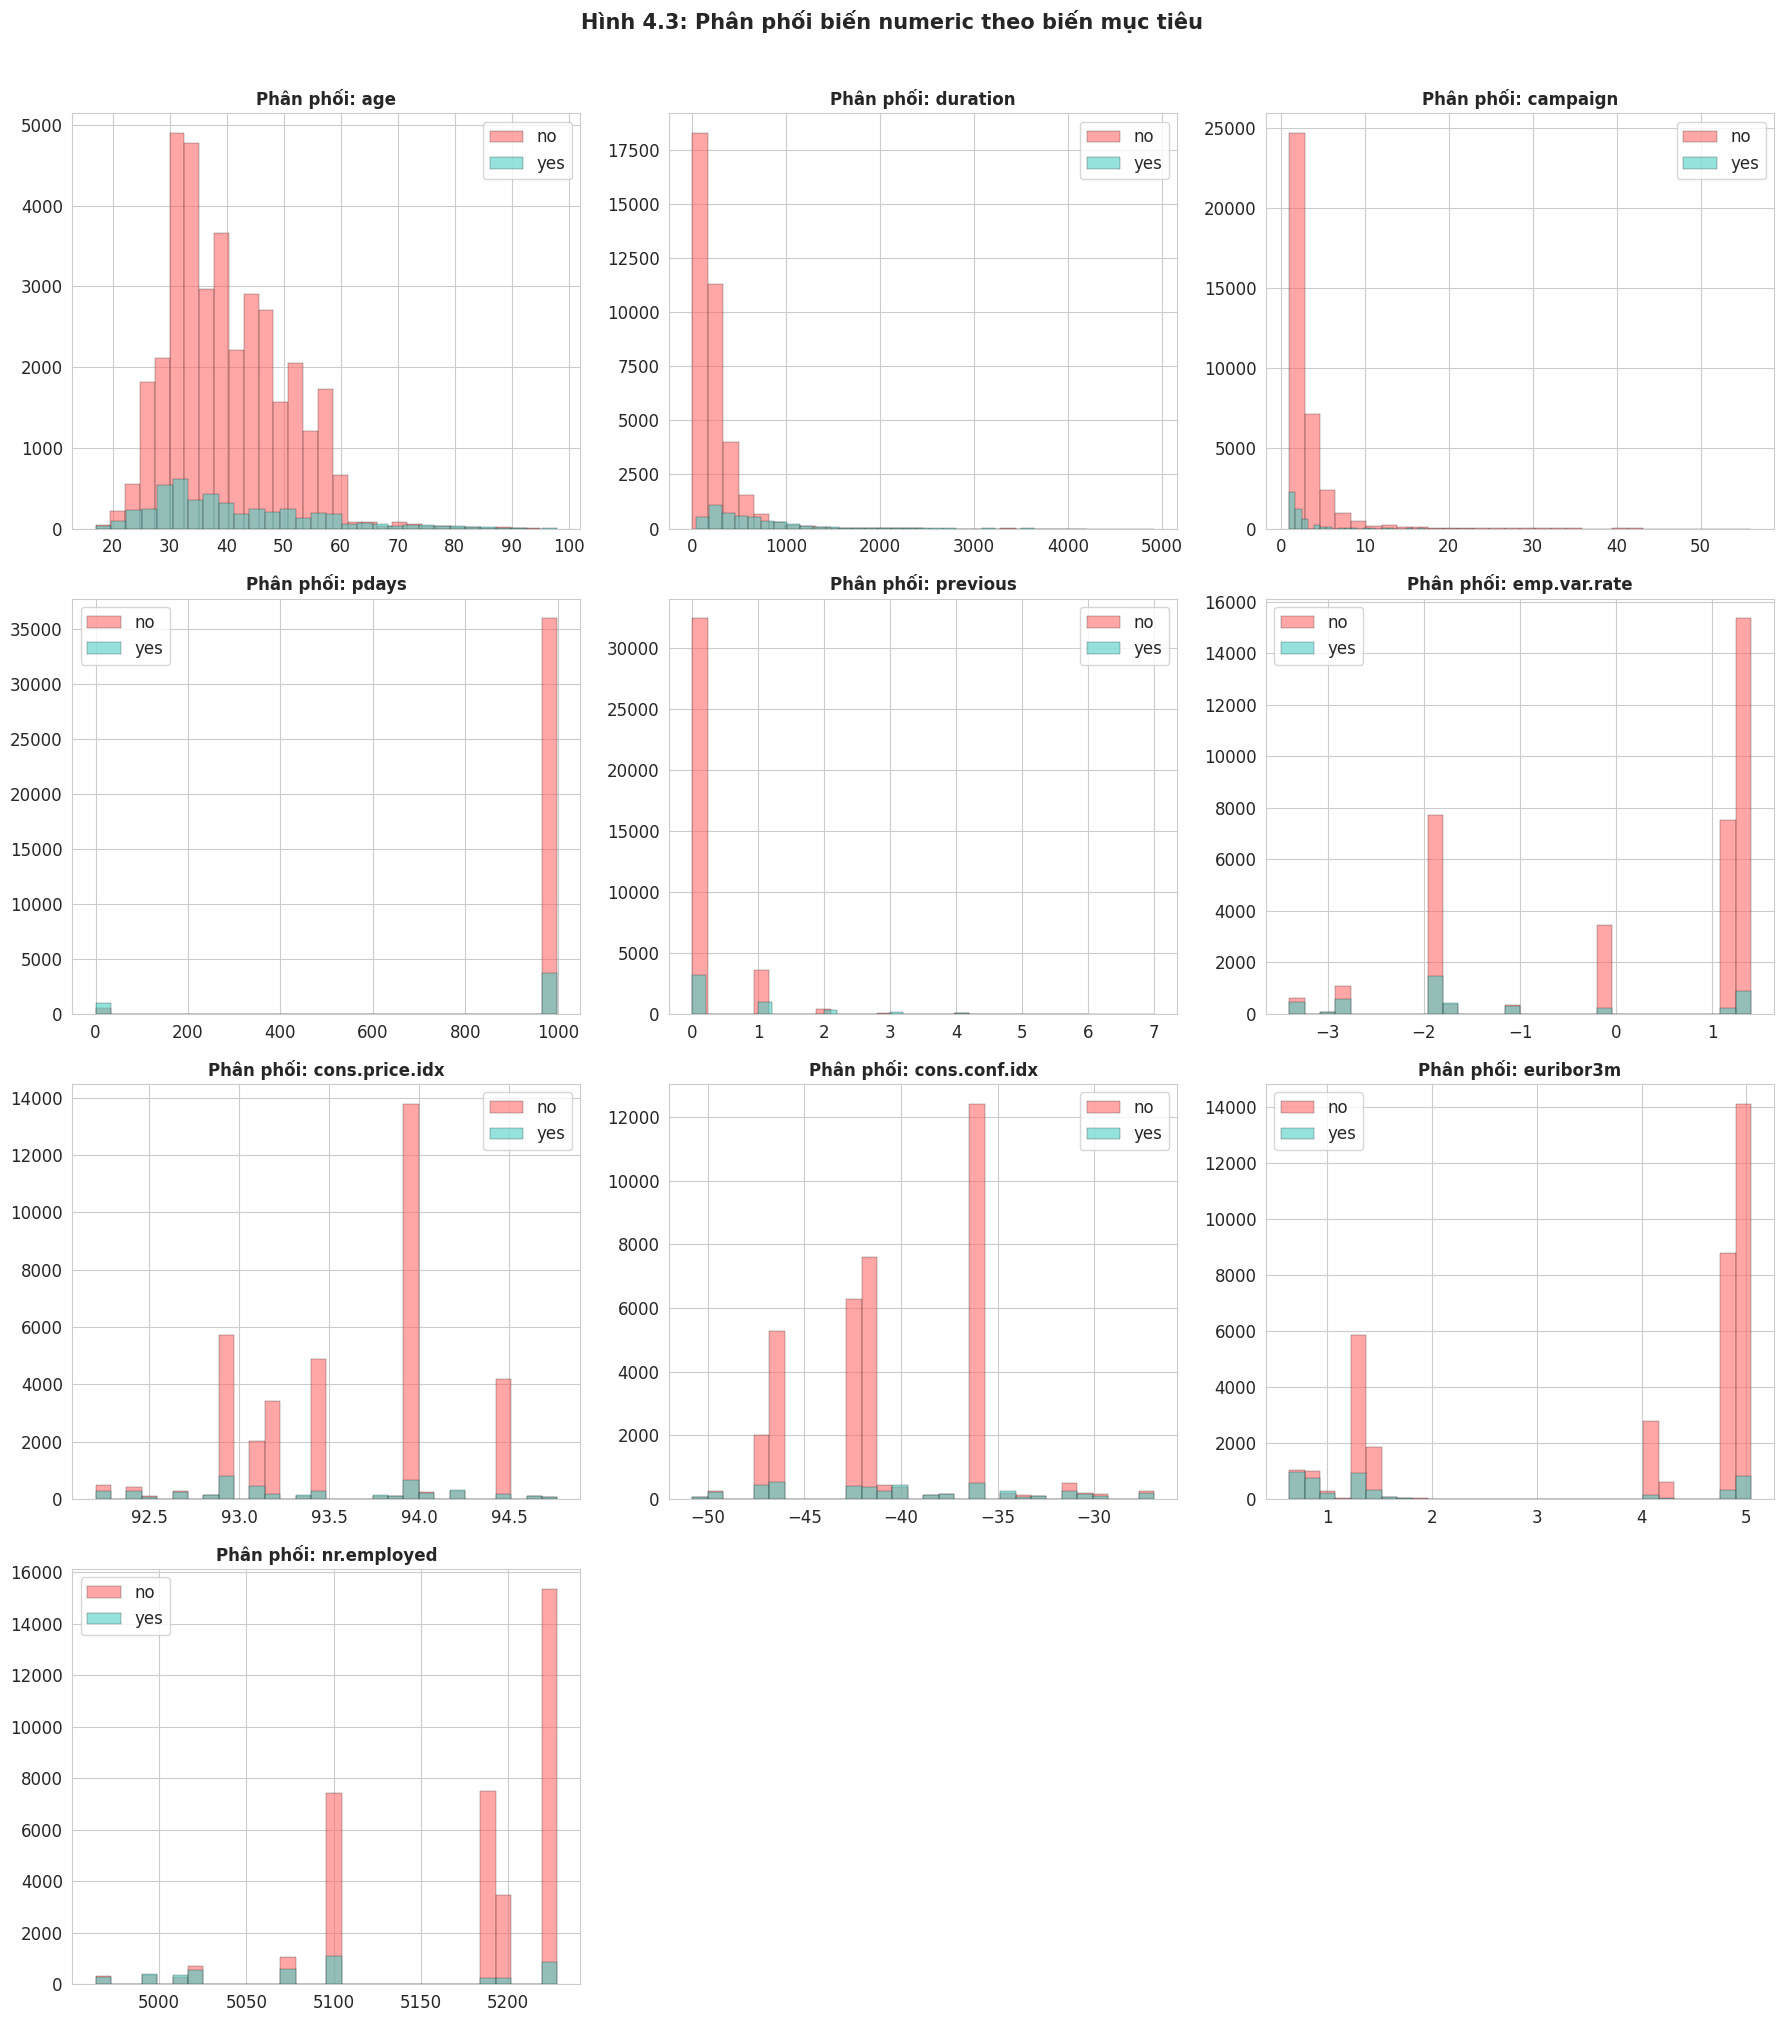

In [12]:
# Phân phối biến numeric
num_cols = ["age", "duration", "campaign", "pdays", "previous",
            "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]

fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    for label, color in zip(["no", "yes"], ["#FF6B6B", "#4ECDC4"]):
        subset = df[df["y"] == label][col]
        ax.hist(subset, bins=30, alpha=0.6, label=label, color=color, edgecolor="black", linewidth=0.3)
    ax.set_title(f"Phân phối: {col}", fontsize=12, fontweight="bold")
    ax.legend()

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Hình 4.3: Phân phối biến numeric theo biến mục tiêu",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("report/fig_4_3_numeric_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


### 4.4 Box plots — Phát hiện outlier


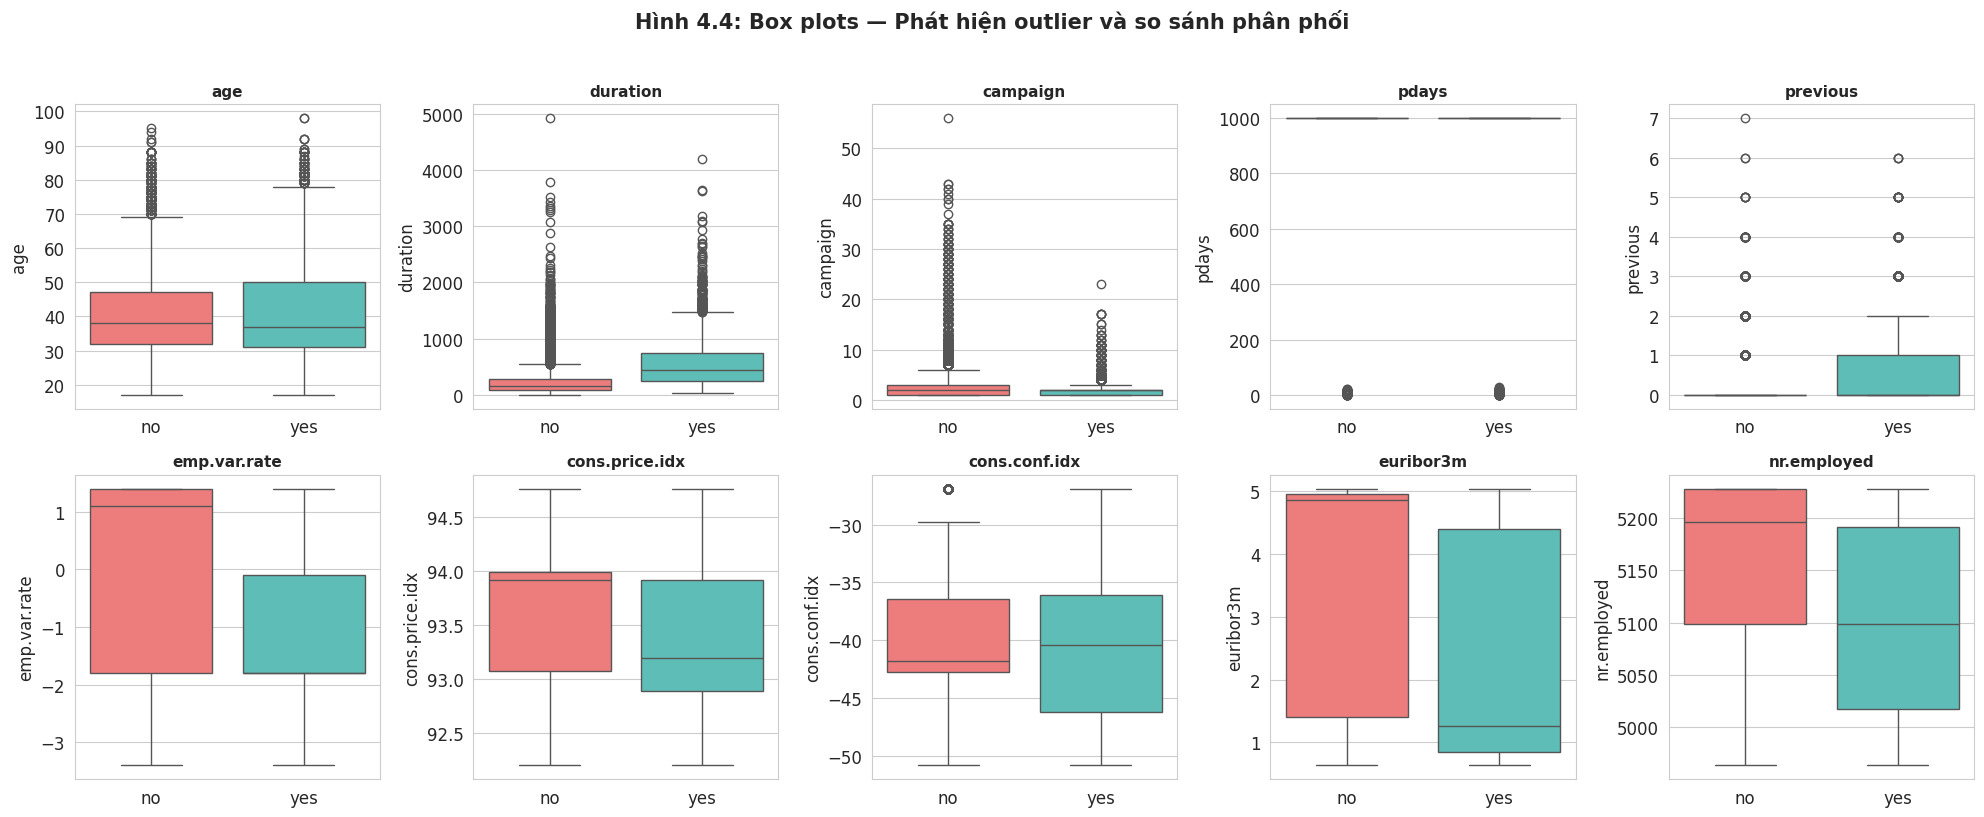

→ Nhận xét:
  - duration: outlier rõ ràng (cuộc gọi > 2000 giây)
  - campaign: outlier (liên hệ > 30 lần)
  - pdays: giá trị 999 = chưa được liên hệ trước đó


In [13]:
# Box plots cho biến numeric
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x="y", y=col, ax=axes[i], palette=["#FF6B6B", "#4ECDC4"])
    axes[i].set_title(f"{col}", fontsize=11, fontweight="bold")
    axes[i].set_xlabel("")

plt.suptitle("Hình 4.4: Box plots — Phát hiện outlier và so sánh phân phối",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("report/fig_4_4_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

print("→ Nhận xét:")
print("  - duration: outlier rõ ràng (cuộc gọi > 2000 giây)")
print("  - campaign: outlier (liên hệ > 30 lần)")
print("  - pdays: giá trị 999 = chưa được liên hệ trước đó")


### 4.5 Correlation Matrix


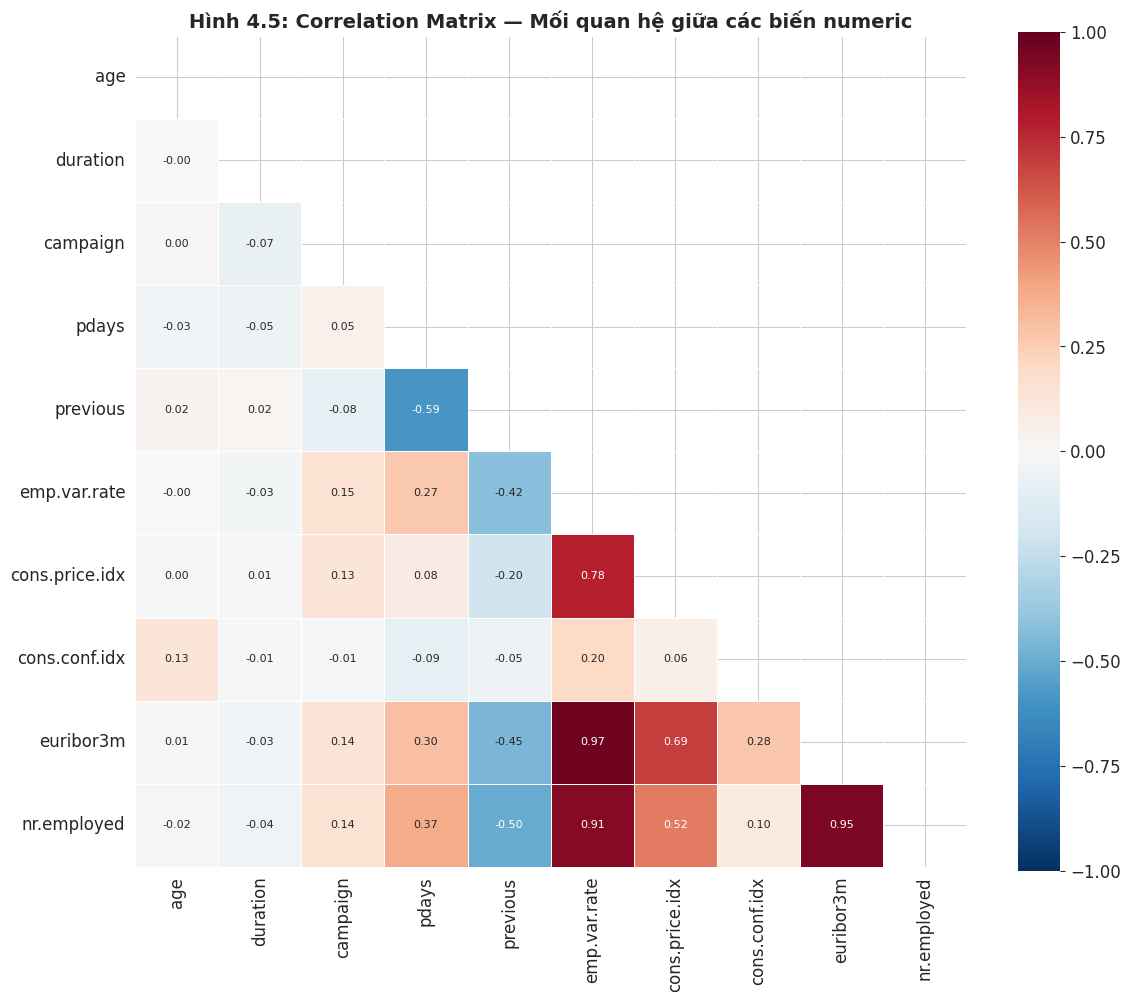

→ Nhận xét quan trọng:
  - euribor3m & emp.var.rate: tương quan cao (r=0.97) → multicollinearity
  - nr.employed & euribor3m: tương quan cao (r=0.95)
  - Cần lưu ý khi phân tích feature importance


In [14]:
# Correlation matrix
num_df = df.select_dtypes(include=[np.number])
corr = num_df.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            annot_kws={"fontsize": 8})
ax.set_title("Hình 4.5: Correlation Matrix — Mối quan hệ giữa các biến numeric",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("report/fig_4_5_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

print("→ Nhận xét quan trọng:")
print("  - euribor3m & emp.var.rate: tương quan cao (r=0.97) → multicollinearity")
print("  - nr.employed & euribor3m: tương quan cao (r=0.95)")
print("  - Cần lưu ý khi phân tích feature importance")


### 4.6 Tỷ lệ Yes/No theo từng thuộc tính categorical


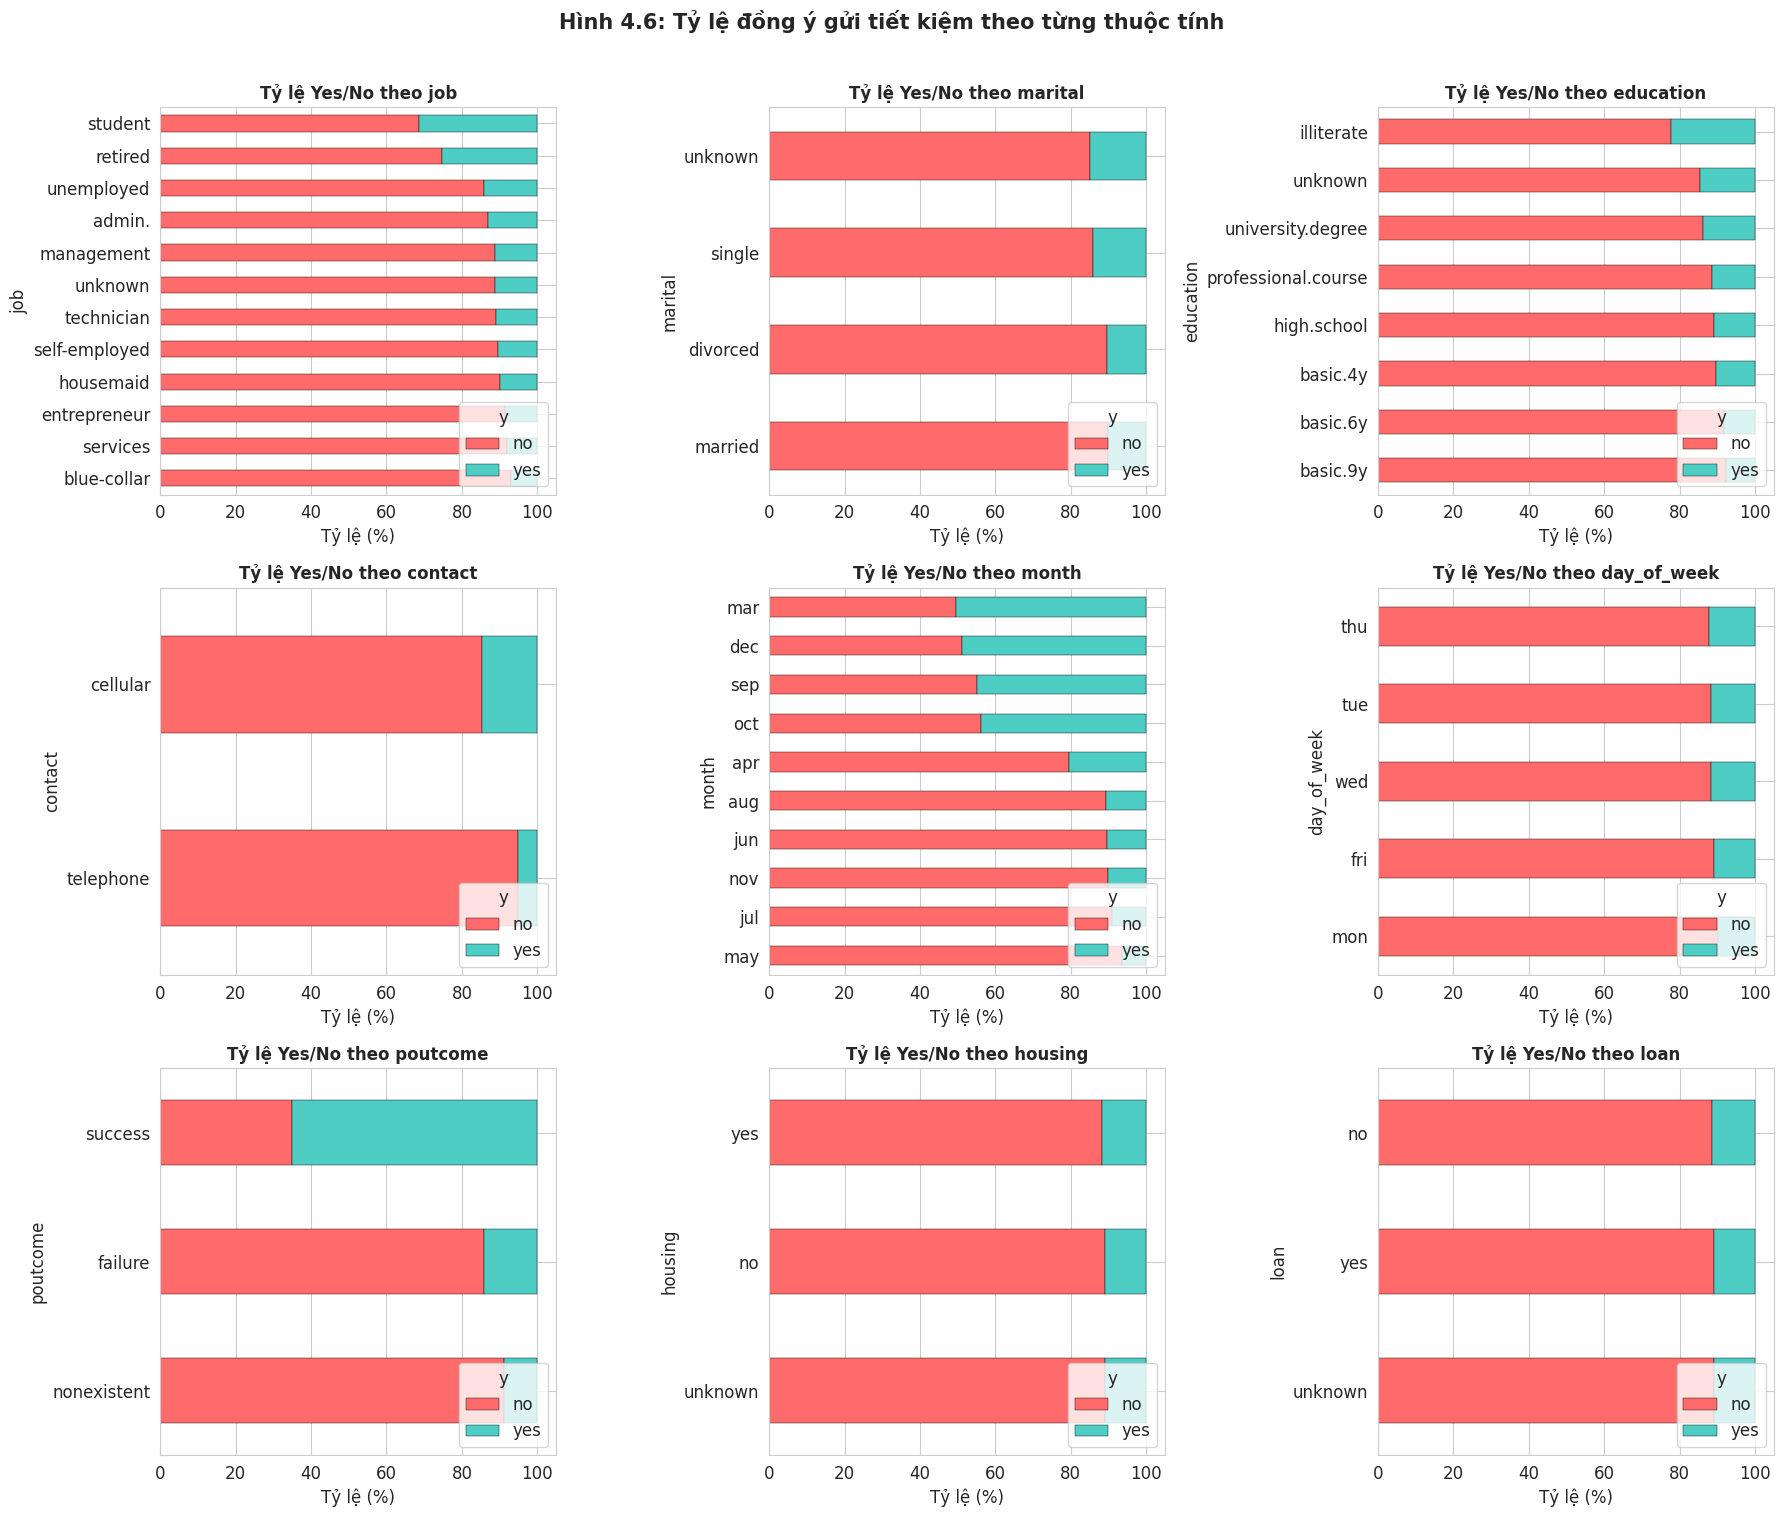

→ Nhận xét:
  - poutcome=success → tỷ lệ yes CAO NHẤT (~65%)
  - contact=cellular → tỷ lệ yes cao hơn telephone
  - month=mar, dec, sep, oct → tỷ lệ yes cao hơn trung bình


In [15]:
# Tỷ lệ yes/no theo categorical
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

important_cats = ["job", "marital", "education", "contact", "month",
                  "day_of_week", "poutcome", "housing", "loan"]

for i, col in enumerate(important_cats):
    ax = axes[i]
    ct = pd.crosstab(df[col], df["y"], normalize="index") * 100
    ct = ct.sort_values("yes", ascending=True)
    ct.plot(kind="barh", stacked=True, ax=ax, color=["#FF6B6B", "#4ECDC4"], edgecolor="black", linewidth=0.3)
    ax.set_title(f"Tỷ lệ Yes/No theo {col}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Tỷ lệ (%)")
    ax.legend(title="y", loc="lower right")

plt.suptitle("Hình 4.6: Tỷ lệ đồng ý gửi tiết kiệm theo từng thuộc tính",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("report/fig_4_6_yes_rate_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

print("→ Nhận xét:")
print("  - poutcome=success → tỷ lệ yes CAO NHẤT (~65%)")
print("  - contact=cellular → tỷ lệ yes cao hơn telephone")
print("  - month=mar, dec, sep, oct → tỷ lệ yes cao hơn trung bình")


### 4.7 Phân tích Duration vs Target


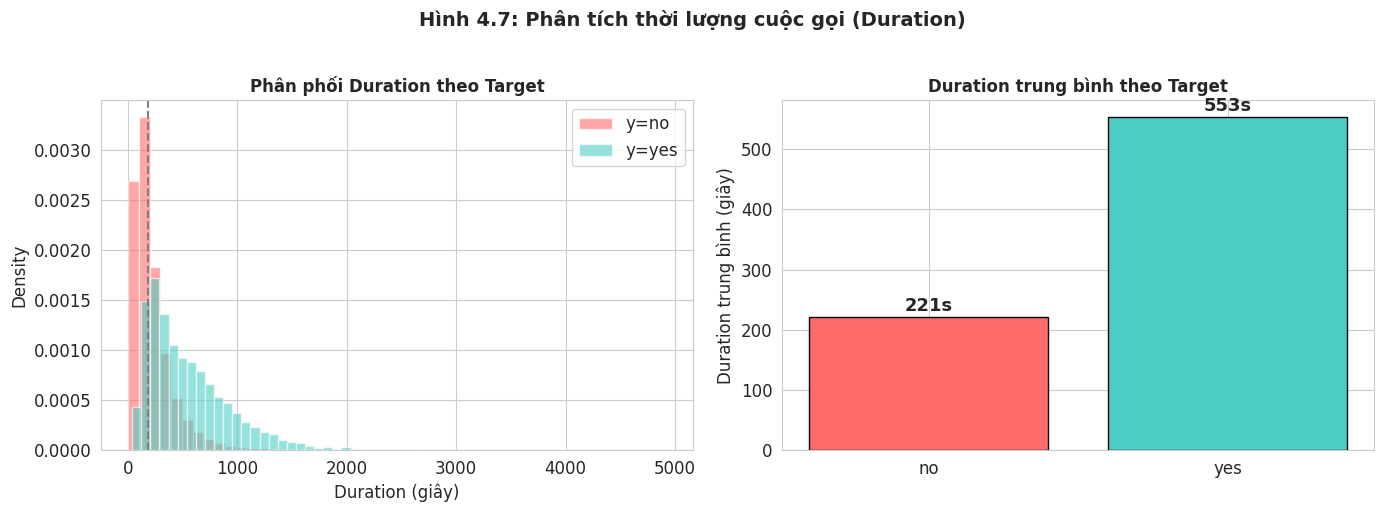

→ Nhận xét: Duration trung bình khi y=yes (553s) 
   gấp ~2.5 lần so với y=no (221s)
   → Duration là feature rất quan trọng cho prediction.


In [16]:
# Duration analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
for label, color in zip(["no", "yes"], ["#FF6B6B", "#4ECDC4"]):
    subset = df[df["y"] == label]["duration"]
    axes[0].hist(subset, bins=50, alpha=0.6, label=f"y={label}", color=color, density=True)
axes[0].set_title("Phân phối Duration theo Target", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Duration (giây)")
axes[0].set_ylabel("Density")
axes[0].legend()
axes[0].axvline(x=df["duration"].median(), color="gray", linestyle="--", label="Median")

# Mean duration by target
means = df.groupby("y")["duration"].mean()
axes[1].bar(means.index, means.values, color=["#FF6B6B", "#4ECDC4"], edgecolor="black")
for i, (idx, val) in enumerate(zip(means.index, means.values)):
    axes[1].text(i, val + 10, f"{val:.0f}s", ha="center", fontsize=13, fontweight="bold")
axes[1].set_title("Duration trung bình theo Target", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Duration trung bình (giây)")

plt.suptitle("Hình 4.7: Phân tích thời lượng cuộc gọi (Duration)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("report/fig_4_7_duration_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"→ Nhận xét: Duration trung bình khi y=yes ({means['yes']:.0f}s) ")
print(f"   gấp ~{means['yes']/means['no']:.1f} lần so với y=no ({means['no']:.0f}s)")
print(f"   → Duration là feature rất quan trọng cho prediction.")


### 4.8 Phân tích Age vs Target


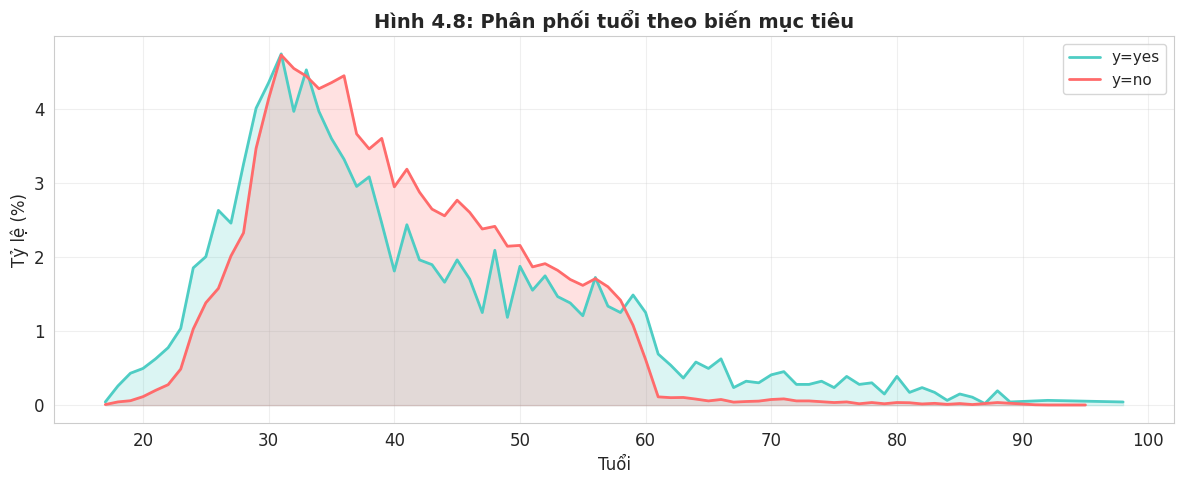

→ Nhận xét: Nhóm tuổi < 30 và > 60 có tỷ lệ yes cao hơn trung bình.


In [17]:
# Age analysis
fig, ax = plt.subplots(figsize=(12, 5))

# Age distribution by target
age_yes = df[df["y"]=="yes"].groupby("age").size() / df[df["y"]=="yes"].shape[0] * 100
age_no = df[df["y"]=="no"].groupby("age").size() / df[df["y"]=="no"].shape[0] * 100

ax.plot(age_yes.index, age_yes.values, label="y=yes", color="#4ECDC4", linewidth=2)
ax.plot(age_no.index, age_no.values, label="y=no", color="#FF6B6B", linewidth=2)
ax.fill_between(age_yes.index, age_yes.values, alpha=0.2, color="#4ECDC4")
ax.fill_between(age_no.index, age_no.values, alpha=0.2, color="#FF6B6B")
ax.set_xlabel("Tuổi", fontsize=12)
ax.set_ylabel("Tỷ lệ (%)", fontsize=12)
ax.set_title("Hình 4.8: Phân phối tuổi theo biến mục tiêu", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("report/fig_4_8_age_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print("→ Nhận xét: Nhóm tuổi < 30 và > 60 có tỷ lệ yes cao hơn trung bình.")


## 5. Phát biểu giả thuyết nghiên cứu (Research Hypothesis)

Dựa trên kết quả EDA, chúng tôi đưa ra các giả thuyết sau:

1. **H1:** Thời lượng cuộc gọi (duration) dài hơn → khả năng đồng ý gửi tiết kiệm cao hơn.
2. **H2:** Kết quả chiến dịch trước (poutcome = "success") là yếu tố dự đoán mạnh nhất.
3. **H3:** Khách hàng trẻ (< 30 tuổi) và già (> 60 tuổi) có tỷ lệ đồng ý cao hơn nhóm trung niên.
4. **H4:** Phương thức liên hệ qua cellular hiệu quả hơn telephone.
5. **H5:** Các chỉ số kinh tế vĩ mô (euribor3m, emp.var.rate) ảnh hưởng đáng kể đến kết quả.

Các giả thuyết này sẽ được kiểm chứng qua mô hình Decision Tree trong các notebook tiếp theo.


## 6. Thiết kế thử nghiệm (Designing Experiments)

### 6.1 Chuẩn bị dữ liệu cho mô hình


In [18]:
# Chuẩn bị dữ liệu
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Tách biến
cat_features = df.select_dtypes(include='object').columns.drop('y').tolist()
num_features = df.select_dtypes(include=[np.number]).columns.tolist()

print(f"Biến categorical ({len(cat_features)}): {cat_features}")
print(f"Biến numeric ({len(num_features)}): {num_features}")

# === LƯU Ý VỀ BIẾN DURATION ===
# Theo UCI: 'duration' chỉ biết SAU cuộc gọi kết thúc.
# Nếu mục tiêu là dự đoán TRƯỚC cuộc gọi → phải loại bỏ.
# Trong đồ án này, chúng tôi GIỮ duration để phân tích benchmark,
# đồng thời chạy thêm thí nghiệm KHÔNG CÓ duration để so sánh.
print("\n⚠️ Lưu ý: Biến 'duration' chỉ biết sau cuộc gọi (xem phân tích chi tiết ở Notebook 2)")

# One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=cat_features, drop_first=False)
print(f"\nSau encoding: {df_encoded.shape[1]} cột (từ {df.shape[1]} cột)")

# === ĐÚNG: Split TRƯỚC, Scale SAU (tránh data leakage) ===
X = df_encoded.drop('y', axis=1).values
y = df_encoded['y'].values
feature_names = df_encoded.drop('y', axis=1).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Lưu ý: Decision Tree KHÔNG CẦN scaling (invariant to monotonic transforms).
# Nhưng nếu muốn scale, phải làm đúng:
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)    # fit trên TRAIN
# X_test_scaled  = scaler.transform(X_test)         # transform TEST (KHÔNG fit lại)
# Ở đây ta KHÔNG scale vì DT không cần.

print(f"\nTrain set: {len(y_train):,} mẫu")
print(f"Test set:  {len(y_test):,} mẫu")
print(f"\nPhân phối y trong train: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Phân phối y trong test:  {dict(zip(*np.unique(y_test, return_counts=True)))}")
print(f"\n→ Stratified split đảm bảo tỷ lệ yes/no giống nhau.")
print(f"→ Không scaling vì Decision Tree invariant to monotonic transforms.")


Biến categorical (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Biến numeric (10): ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

⚠️ Lưu ý: Biến 'duration' chỉ biết sau cuộc gọi (xem phân tích chi tiết ở Notebook 2)

Sau encoding: 64 cột (từ 21 cột)

Train set: 32,940 mẫu
Test set:  8,236 mẫu

Phân phối y trong train: {'no': np.int64(29229), 'yes': np.int64(3711)}
Phân phối y trong test:  {'no': np.int64(7308), 'yes': np.int64(928)}

→ Stratified split đảm bảo tỷ lệ yes/no giống nhau.
→ Không scaling vì Decision Tree invariant to monotonic transforms.


In [ ]:
# Lưu data đã xử lý
import pickle

data = {
    'X_train': X_train, 'X_test': X_test,
    'y_train': y_train, 'y_test': y_test,
    'feature_names': feature_names,
    'num_features': num_features,
    'cat_features': cat_features,
}

with open('data/processed_data.pkl', 'wb') as f:
    pickle.dump(data, f)

print('✅ Dữ liệu đã xử lý được lưu tại: data/processed_data.pkl')
print(f'   X_train: {X_train.shape}')
print(f'   X_test:  {X_test.shape}')
print(f'   Features: {len(feature_names)} cột')


## Tóm tắt

| Bước | Nội dung | Kết quả |
|---|---|---|
| 1 | Kiểm tra null | Không có null |
| 2 | Kiểm tra implicit missing | "unknown" trong job, education, default, housing, loan → giữ nguyên |
| 3 | Kiểm tra duplicate | Có 12 bản ghi trùng → đã xóa |
| 4 | EDA | 8 nhóm biểu đồ phân tích chi tiết |
| 5 | Chuẩn hóa | StandardScaler cho biến numeric |
| 6 | Encoding | One-Hot Encoding cho biến categorical |
| 7 | Train/Test Split | 80/20 stratified |

**Dữ liệu sẵn sàng cho Notebook 2 (From Scratch) và Notebook 3 (Sklearn).**
